# 📘 Notebook 01 — Exploration des données

# Chargement des données

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/water_potability.csv")
df.head()


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


# Dimensions types et valeurs manquantes

In [5]:
# Dimensions du dataset
print("Shape :", df.shape)

Shape : (3276, 10)


In [6]:
# Types des colonnes
print("\nDtypes :")
print(df.dtypes)


Dtypes :
ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object


In [7]:
# Valeurs manquantes
print("\nMissing values :")
print(df.isna().sum())


Missing values :
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


# Statistiques descriptives

In [4]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


# Matrice de corrélation

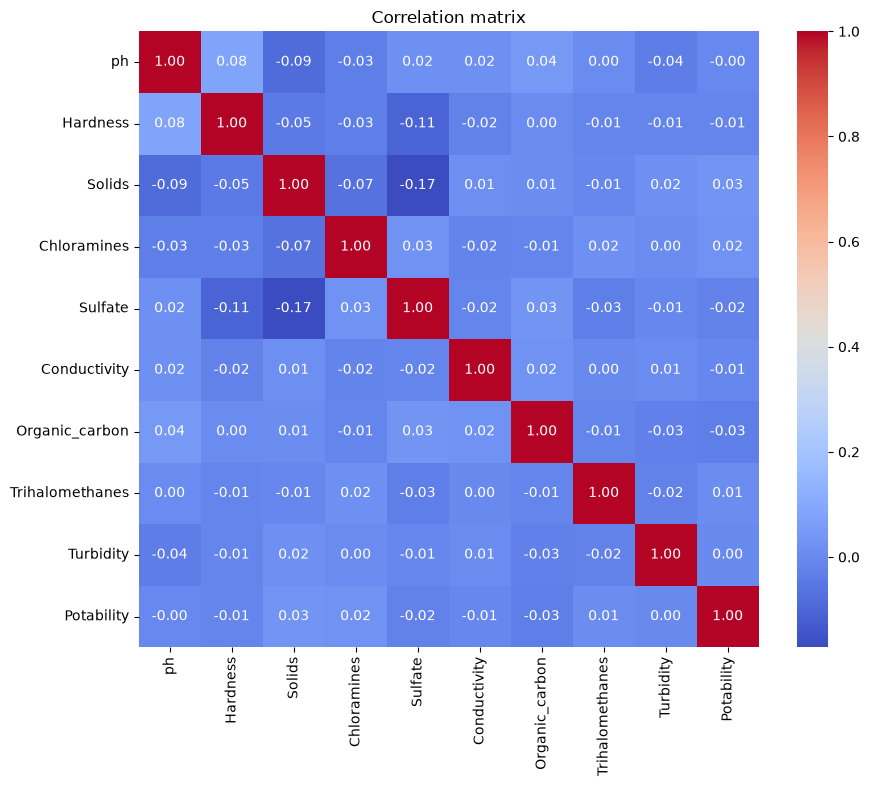

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix")
plt.show()


In [16]:
# Tableau de corrélations globales
corr_table = df.corr()

corr_table


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
ph,1.000000,0.082096,-0.089288,-0.034350,0.018203,0.018614,0.043503,0.003354,-0.039057,-0.003556
Hardness,0.082096,1.000000,-0.046899,-0.030054,-0.106923,-0.023915,0.003610,-0.013013,-0.014449,-0.013837
Solids,-0.089288,-0.046899,1.000000,-0.070148,-0.171804,0.013831,0.010242,-0.009143,0.019546,0.033743
Chloramines,-0.034350,-0.030054,-0.070148,1.000000,0.027244,-0.020486,-0.012653,0.017084,0.002363,0.023779
Sulfate,0.018203,-0.106923,-0.171804,0.027244,1.000000,-0.016121,0.030831,-0.030274,-0.011187,-0.023577
Conductivity,0.018614,-0.023915,0.013831,-0.020486,-0.016121,1.000000,0.020966,0.001285,0.005798,-0.008128
Organic_carbon,0.043503,0.003610,0.010242,-0.012653,0.030831,0.020966,1.000000,-0.013274,-0.027308,-0.030001
Trihalomethanes,0.003354,-0.013013,-0.009143,0.017084,-0.030274,0.001285,-0.013274,1.000000,-0.022145,0.007130
Turbidity,-0.039057,-0.014449,0.019546,0.002363,-0.011187,0.005798,-0.027308,-0.022145,1.000000,0.001581
Potability,-0.003556,-0.013837,0.033743,0.023779,-0.023577,-0.008128,-0.030001,0.007130,0.001581,1.000000


In [17]:
# Corrélations avec la cible Potability
target_corr = df.corr()["Potability"].sort_values(ascending=False)

target_corr


Potability         1.000000
Solids             0.033743
Chloramines        0.023779
Trihalomethanes    0.007130
Turbidity          0.001581
ph                -0.003556
Conductivity      -0.008128
Hardness          -0.013837
Sulfate           -0.023577
Organic_carbon    -0.030001
Name: Potability, dtype: float64

In [18]:
print("=== Rapport automatique de corrélations ===\n")

for feature, value in target_corr.items():
    if feature != "Potability":
        print(f"{feature:20s} → corr = {value:.3f}")


=== Rapport automatique de corrélations ===

Solids               → corr = 0.034
Chloramines          → corr = 0.024
Trihalomethanes      → corr = 0.007
Turbidity            → corr = 0.002
ph                   → corr = -0.004
Conductivity         → corr = -0.008
Hardness             → corr = -0.014
Sulfate              → corr = -0.024
Organic_carbon       → corr = -0.030


In [19]:
print("\n=== Interprétation automatique ===\n")

for feature, value in target_corr.items():
    if feature != "Potability":
        if abs(value) < 0.1:
            level = "faible"
        elif abs(value) < 0.3:
            level = "modérée"
        else:
            level = "forte"

        print(f"{feature:20s} → corr = {value:.3f} ({level})")



=== Interprétation automatique ===

Solids               → corr = 0.034 (faible)
Chloramines          → corr = 0.024 (faible)
Trihalomethanes      → corr = 0.007 (faible)
Turbidity            → corr = 0.002 (faible)
ph                   → corr = -0.004 (faible)
Conductivity         → corr = -0.008 (faible)
Hardness             → corr = -0.014 (faible)
Sulfate              → corr = -0.024 (faible)
Organic_carbon       → corr = -0.030 (faible)


In [20]:
import pandas as pd

# Corrélations avec la cible
corr_target = df.corr()["Potability"].drop("Potability")

# Création d'un tableau enrichi
corr_report = pd.DataFrame({
    "Correlation": corr_target,
    "AbsCorrelation": corr_target.abs()
})

# Tri par corrélation absolue
corr_report = corr_report.sort_values("AbsCorrelation", ascending=False)

# Interprétation automatique
def interpret(c):
    if abs(c) < 0.1:
        return "Faible"
    elif abs(c) < 0.3:
        return "Modérée"
    else:
        return "Forte"

corr_report["Interpretation"] = corr_report["Correlation"].apply(interpret)

corr_report


,Correlation,AbsCorrelation,Interpretation
Solids,0.033743,0.033743,Faible
Organic_carbon,-0.030001,0.030001,Faible
Chloramines,0.023779,0.023779,Faible
Sulfate,-0.023577,0.023577,Faible
Hardness,-0.013837,0.013837,Faible
Conductivity,-0.008128,0.008128,Faible
Trihalomethanes,0.007130,0.007130,Faible
ph,-0.003556,0.003556,Faible
Turbidity,0.001581,0.001581,Faible


# 📄 Conclusion scientifique — Analyse exploratoire des données
## 1. Caractéristiques générales du jeu de données
Le jeu de données analysé comporte 3276 observations et 10 variables, dont 9 paramètres physico‑chimiques de la qualité de l’eau (pH, dureté, solides dissous, chloramines, sulfate, conductivité, carbone organique, trihalométhanes, turbidité) et une variable cible binaire indiquant la potabilité.
L’ensemble des variables explicatives est de nature numérique continue, ce qui facilite l’application de méthodes statistiques et de modèles d’apprentissage supervisé.

## 2. Analyse des valeurs manquantes
Trois variables présentent des proportions significatives de valeurs manquantes :

- pH : 491 valeurs manquantes (~15 %)

- Sulfate : 781 valeurs manquantes (~24 %)

- Trihalomethanes : 162 valeurs manquantes (~5 %)

La présence de ces lacunes est cohérente avec des mesures environnementales hétérogènes.
Une stratégie d’imputation adaptée sera nécessaire afin de limiter les biais potentiels dans les phases de modélisation.

## 3. Distribution et variabilité des paramètres
Les paramètres physico‑chimiques présentent une variabilité importante, notamment :

- Solids (TDS) : étendue très large (320 à 61 227 mg/L)

- Conductivity : variation notable (181 à 753 μS/cm)

- Organic_carbon : valeurs comprises entre 2.2 et 28.3 mg/L

Ces distributions suggèrent la présence d’outliers et de conditions environnementales très hétérogènes.
Une étape de détection et de traitement des valeurs extrêmes sera indispensable pour stabiliser les futures phases de modélisation.

## 4. Analyse des corrélations
L’analyse des corrélations linéaires révèle que aucune variable ne présente une relation significative avec la potabilité.
Les coefficients de corrélation avec la cible sont tous compris entre −0.03 et +0.03, ce qui correspond à des corrélations faibles selon les seuils usuels en statistique.

Ces résultats impliquent que :

- la potabilité ne dépend pas d’un seul paramètre, mais d’une combinaison non linéaire de facteurs ;

- les modèles linéaires (régression logistique, SVM linéaire) seront probablement peu performants ;

- des modèles non linéaires (RandomForest, GradientBoosting, XGBoost) seront mieux adaptés pour capturer les interactions complexes entre variables.

## 5. Implications pour la modélisation
Les observations précédentes impliquent que la phase de préparation des données devra inclure :

- Imputation des valeurs manquantes

    - médiane, KNN imputer, ou imputation multiple.

- Traitement des outliers

    - méthodes IQR, z‑score, ou modèles d’isolation (Isolation Forest).

- Normalisation ou standardisation

    - nécessaire pour homogénéiser les échelles des variables.

- Feature engineering basé sur les normes OMS et EPA

    - indicateurs de dépassement des seuils réglementaires ;

    - interactions entre paramètres (ex. TDS × Conductivity) ;

    - catégorisation des niveaux de pH, dureté, turbidité.

- Sélection de modèles non linéaires

    - RandomForestClassifier 

    - GradientBoostingClassifier 

    - XGBoost 

# 6. Conclusion générale
L’analyse exploratoire met en évidence un jeu de données complexe, hétérogène, et faiblement corrélé à la cible, nécessitant une préparation approfondie avant la modélisation.
Les prochaines étapes consisteront à :

- nettoyer les données (Notebook 02),

- construire des variables pertinentes (Notebook 03),

- entraîner un modèle non linéaire robuste (Notebook 04).

